In [6]:
import torch
import os
from build_model import CrossAV

In [7]:
os.getcwd()


'/Users/Shared/RAVE/Workspaces/haotian/avhubert/LRS_processing'

In [8]:

# ---- Load checkpoint ----
ckpt_path = "./LRS2/checkpoints/Aug24_test/best.pt"
payload = torch.load(ckpt_path, map_location="cpu")

# Rebuild your model (must match training config!)
model = CrossAV(
    phoneme_vocab_size=43,
    a_drop_modality_prob=0.0,
    v_drop_modality_prob=0.0,
    return_attn=True,
    fusion_mask_type="causal_band",
    fusion_band=5,
    use_q_proj=True,
    use_k_proj=True,
    use_v_proj=True,
    tcn_hidden=128,
    tcn_layers=2,
    tcn_kernel=3,
    tcn_dropout=0.1,
    tcn_dilation_base=2,
)

model.load_state_dict(payload["model_state"])
model.eval()


/var/folders/jx/t6p8dp8j3_98g_gs99jtrv_h0000gn/T/ipykernel_5221/2482332461.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(ckpt_path, map_location="

CrossAV(
  (audio_encoder): AuditoryEncoder(
    (encoder): Sequential(
      (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): AdaptiveAvgPool2d(output_size=(1, None))
    )
  )
  (visual_encoder): VisualEncoder(
    (encoder): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=

In [13]:
import os, cv2, torch, torchaudio
import torch.nn.functional as F

# -------- params: match your encoders --------
TARGET_AUDIO_SR = 16000
N_MFCC          = 26            # your collate used 26
H, W            = 96, 96        # VisualEncoder expects 96x96
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- audio: load -> resample -> MFCC -> (T, n_mfcc) ----------
def load_audio_mfcc(audio_path, target_sr=TARGET_AUDIO_SR, n_mfcc=N_MFCC):
    wav, sr = torchaudio.load(audio_path)               # (1, n_samples) or (C, n)
    if wav.dim() == 2 and wav.size(0) > 1:
        wav = wav.mean(dim=0, keepdim=True)             # mono
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)

    # MFCC (you can tweak n_mels, win_length, hop_length, etc.)
    mfcc_fn = torchaudio.transforms.MFCC(
        sample_rate=target_sr,
        n_mfcc=n_mfcc,
        melkwargs={"n_fft": 400, "hop_length": 640,"n_mels": 32}
    )
    mfcc = mfcc_fn(wav)                                 # (1, n_mfcc, T_audio)
    mfcc = mfcc.squeeze(0).transpose(0, 1).contiguous() # -> (T_audio, n_mfcc)
    return mfcc.float()

# ---------- video: load frames -> grayscale -> resize -> (T, H, W) ----------
def load_video_tensor(video_path, target_hw=(H, W), max_frames=None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    frames = []
    count = 0
    while True:
        ok, frame = cap.read()
        if not ok: break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)     # grayscale
        frame = cv2.resize(frame, target_hw, interpolation=cv2.INTER_AREA)
        frame = torch.from_numpy(frame).float() / 255.0     # [0,1], (H,W)
        frames.append(frame)
        count += 1
        if max_frames is not None and count >= max_frames:
            break
    cap.release()
    if len(frames) == 0:
        raise RuntimeError("No frames decoded from video.")
    vid = torch.stack(frames, dim=0)                        # (T_video, H, W)
    return vid

# ---------- simple time alignment: resample audio to video length ----------
def align_audio_to_video(mfcc_Tn, T_video):
    """
    mfcc_Tn: (T_a, n_mfcc)
    returns (T_video, n_mfcc) by linear interpolation along time.
    """
    Ta, C = mfcc_Tn.shape
    x = mfcc_Tn.transpose(0,1).unsqueeze(0)         # (1, C, Ta)
    x = F.interpolate(x, size=T_video, mode="linear", align_corners=False)
    x = x.squeeze(0).transpose(0,1).contiguous()    # (T_video, C)
    return x

# ---------- run one example ----------
def run_one(model, audio_path, video_path):
    # 1) load raw features
    mfcc = load_audio_mfcc(audio_path)                  # (T_a, n_mfcc)
    video = load_video_tensor(video_path)               # (T_v, H, W)

    # 2) align lengths (your CrossAV currently asserts Ta == Tv in AV mode)
    T_v = video.shape[0]
    mfcc_aligned = align_audio_to_video(mfcc, T_v)      # (T_v, n_mfcc)

    # 3) batch + lengths
    audio_tensor = mfcc_aligned.unsqueeze(0).to(DEVICE) # (1, T, n_mfcc)
    video_tensor = video.unsqueeze(0).to(DEVICE)        # (1, T, H, W)
    lengths      = torch.tensor([T_v], dtype=torch.long, device=DEVICE)

    # 4) forward (return_attn=True in your model to get attention maps)
    model = model.to(DEVICE).eval()
    with torch.no_grad():
        logits, attn = model(
            audio_tensor=audio_tensor,
            visual_tensor=video_tensor,
            mode="av",
            lengths_audio=lengths,      # build key_padding_mask for audio K/V
            lengths_video=lengths,
            attn_mask=None
        )

    print("logits:", tuple(logits.shape))  # (B, T, C)
    print("attn:  ", tuple(attn.shape))    # (B, H, Tq, Tk)
    return logits.cpu(), attn.cpu()


In [14]:

# ---------------- example usage ----------------
if __name__ == "__main__":
    # Rebuild model EXACTLY as trained (args must match checkpoint)
    model = CrossAV(
        phoneme_vocab_size=43,
        a_drop_modality_prob=0.0,
        v_drop_modality_prob=0.0,
        return_attn=True,
        fusion_mask_type="causal_band",
        fusion_band=5,
        use_q_proj=True,
        use_k_proj=True,
        use_v_proj=True,
        tcn_hidden=128,
        tcn_layers=2,
        tcn_kernel=3,
        tcn_dropout=0.1,
        tcn_dilation_base=2,
    )


    # Paths to arbitrary audio/video files you want to test
    audio_path = "../data/stimuli/Aug1_new_F01_C1_C2/MS1_F01_C1_new.wav"    # e.g., 16kHz mono WAV (others resampled)
    video_path = "../data/stimuli/Aug1_new_F01_C1_C2/MS1_F01_C1_new_roi.mp4"    # any codec OpenCV can read

    logits, attn = run_one(model, audio_path, video_path)




logits: (1, 60, 43)
attn:   (1, 8, 60, 60)


In [19]:
import matplotlib.pyplot as plt
import json

In [23]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def _idx_to_phoneme_list(phoneme_to_idx, vocab_size=None):
    """Build a list mapping row index -> label (0..C-1)."""
    if vocab_size is None:
        vocab_size = max(phoneme_to_idx.values()) + 1
    inv = {v: k for k, v in phoneme_to_idx.items()}
    labels = [inv.get(i, str(i)) for i in range(vocab_size)]
    return labels

def plot_attention_heads(attn, sample=0, heads=None, cmap="viridis",
                         tick_every=10, figsize_per_head=(4, 3), suptitle=None):
    """
    attn: (B, H, Tq, Tk) attention weights (after softmax)
    Plots one heatmap per head for the chosen sample index.
    """
    assert attn.dim() == 4, f"Expected (B,H,Tq,Tk), got {tuple(attn.shape)}"
    B, H, Tq, Tk = attn.shape
    attn_s = attn.detach().cpu().float()[sample]  # (H, Tq, Tk)

    head_indices = list(range(H)) if heads is None else list(heads)
    n_heads = len(head_indices)

    # Make a compact grid of figures, one per head
    for h in head_indices:
        a = attn_s[h]  # (Tq, Tk)
        plt.figure(figsize=figsize_per_head)
        plt.imshow(a, aspect="auto", origin="lower", cmap=cmap)
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.title(f"Attention Head {h} — sample {sample} (Tq={Tq}, Tk={Tk})")
        # ticks (downsampled for readability)
        xticks = np.arange(0, Tk, max(1, tick_every))
        yticks = np.arange(0, Tq, max(1, tick_every))
        plt.xticks(xticks)
        plt.yticks(yticks)
        plt.xlabel("Key time (k)")
        plt.ylabel("Query time (q)")
        plt.tight_layout()

    if suptitle:
        plt.suptitle(suptitle)
        plt.tight_layout()

def plot_logits_heatmap(logits, phoneme_to_idx, sample=0, use_log_probs=True,
                        cmap="magma", tick_every=10, clip_percentile=0.0,
                        figsize=(8, 6)):
    """
    logits: (B, T, C) BEFORE softmax
    phoneme_to_idx: dict {'<BLANK>':0, 'AA':1, ...}
    use_log_probs: if True, plot log_softmax; else raw logits or probs.
    clip_percentile: clip colormap limits to improve contrast (e.g., 1.0 or 2.0)
    """
    assert logits.dim() == 3, f"Expected (B,T,C), got {tuple(logits.shape)}"
    B, T, C = logits.shape
    x = logits.detach().cpu().float()[sample]  # (T, C)

    if use_log_probs:
        x = x.log_softmax(dim=-1)  # (T,C)
        title = f"log_probs — sample {sample} (T={T}, C={C})"
    else:
        # You could use probs for visualization instead:
        # x = x.softmax(dim=-1)
        title = f"logits — sample {sample} (T={T}, C={C})"

    # (rows, cols) = (C, T): rows=phonemes, cols=time
    mat = x.transpose(0, 1).numpy()  # (C, T)

    # optional clipping to improve heatmap contrast
    if clip_percentile and clip_percentile > 0:
        lo = np.percentile(mat, clip_percentile)
        hi = np.percentile(mat, 100 - clip_percentile)
        vmin, vmax = lo, hi
    else:
        vmin = vmax = None

    labels = _idx_to_phoneme_list(phoneme_to_idx, vocab_size=C)

    plt.figure(figsize=figsize)
    im = plt.imshow(mat, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)

    # ticks
    xticks = np.arange(0, T, max(1, tick_every))
    yticks = np.arange(0, C, max(1, max(C // 40, 1)))  # avoid overplotting labels
    plt.xticks(xticks)
    plt.yticks(yticks, [labels[i] for i in yticks])

    plt.xlabel("Time")
    plt.ylabel("Phoneme")
    plt.tight_layout()

# ------------------------ Example usage ------------------------
# logits: (B, T, C), attn: (B, H, Tq, Tk), phoneme_to_idx: dict
# plot_attention_heads(attn, sample=0, heads=None, tick_every=5)
# plot_logits_heatmap(logits, phoneme_to_idx, sample=0, use_log_probs=True, tick_every=5, clip_percentile=2.0)


In [21]:
phoneme_to_idx

{'<BLANK>': 0,
 'AA': 1,
 'AE': 2,
 'AH': 3,
 'AO': 4,
 'AW': 5,
 'AY': 6,
 'B': 7,
 'CH': 8,
 'D': 9,
 'DH': 10,
 'DX': 11,
 'EH': 12,
 'ER': 13,
 'EY': 14,
 'F': 15,
 'G': 16,
 'HH': 17,
 'IH': 18,
 'IY': 19,
 'JH': 20,
 'K': 21,
 'L': 22,
 'M': 23,
 'N': 24,
 'NG': 25,
 'OW': 26,
 'OY': 27,
 'P': 28,
 'R': 29,
 'S': 30,
 'SH': 31,
 'SIL': 32,
 'SPN': 33,
 'T': 34,
 'TH': 35,
 'UH': 36,
 'UW': 37,
 'V': 38,
 'W': 39,
 'Y': 40,
 'Z': 41,
 'ZH': 42}

In [20]:
phone_to_idx_path="./LRS2/LRS_main_labelled_data/cmu_phoneme_to_idx.json"
with open(phone_to_idx_path, 'r') as f:
    phoneme_to_idx = json.load(f)

In [22]:
# (Optional) quick sanity peeks
print("First 5 time steps, top-5 class logits (sample 0):")
with torch.no_grad():
    top5 = torch.topk(logits[0, :5], k=5, dim=-1).indices
    print(top5)

First 5 time steps, top-5 class logits (sample 0):
tensor([[25, 31, 10, 26, 37],
        [26, 37, 25, 10,  5],
        [26, 42,  2, 37, 25],
        [26, 42, 37,  2,  7],
        [26, 42, 37, 30, 24]])


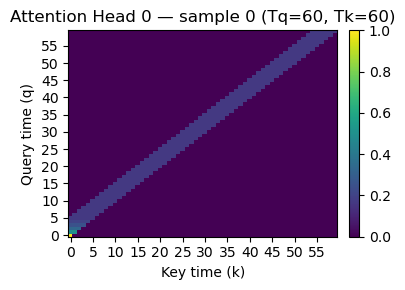

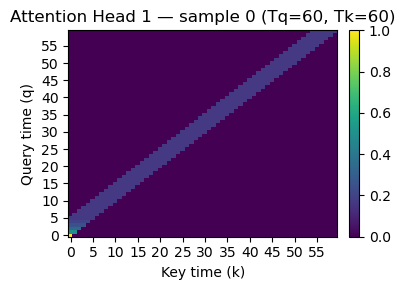

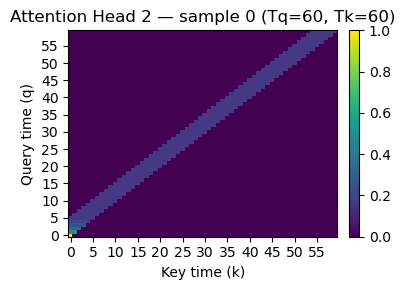

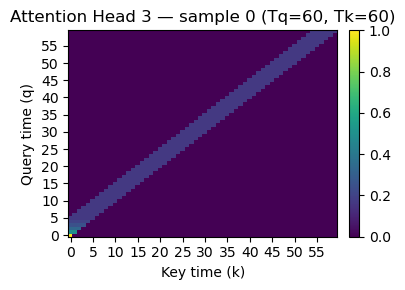

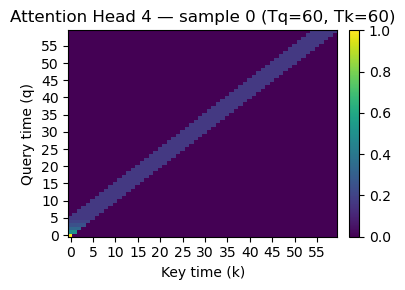

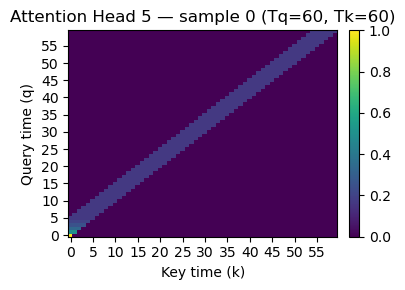

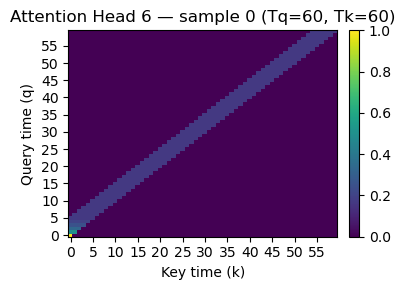

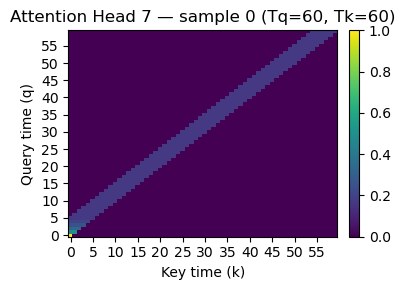

In [24]:
# ------------------------ Example usage ------------------------
plot_attention_heads(attn, sample=0, heads=None, tick_every=5)



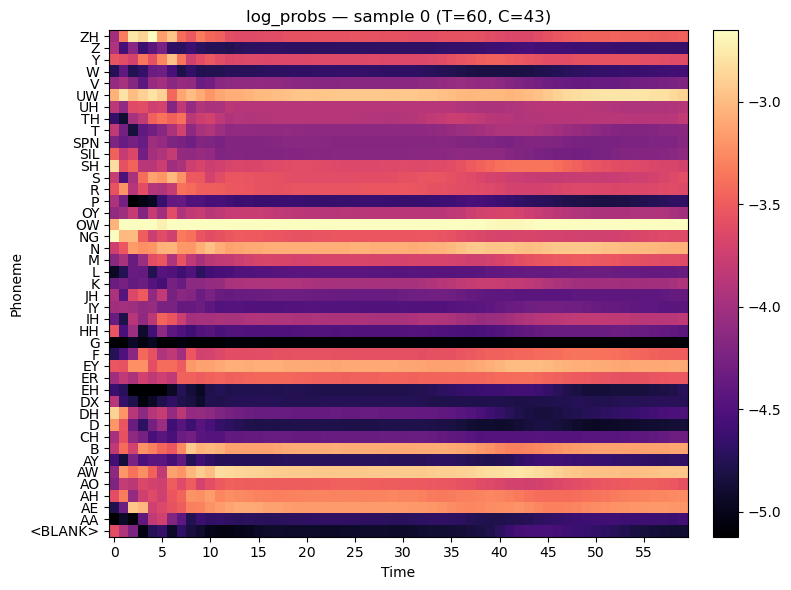

In [25]:
plot_logits_heatmap(logits, phoneme_to_idx, sample=0, use_log_probs=True, tick_every=5, clip_percentile=2.0)